# Search Engines: From Toy to Production

## Session Map & Learning Goals

In this notebook we will **build a toy search engine** step by step, and link each part to how real systems (like Elasticsearch) work.

**What we will do today**
1. **Understand the building blocks of search**:
   - Tokenization, normalization
   - Inverted index
   - Ranking with TF–IDF
   - PageRank intuition
2. **Work on a *tiny corpus* by hand + code**:
   - See postings lists and term statistics
   - Compute scores for toy queries
   - Run PageRank on a 4–5 node web graph
3. **Bridge to production**:
   - How these toy ideas scale up
   - Preview Elasticsearch as a “productionish” search engine

**Why this matters**
- Search is at the heart of every information system (web, enterprise docs, e-commerce).
- Understanding the toy version helps you reason about the *engineering challenges* of scale.

---

# Minimal requirements for toy_search notebook
numpy>=1.23


## Tiny Corpus & Notation

To make the concepts concrete, we will work with a **very small set of documents**.

**Toy Document Collection (4 docs)**  
- **D1:** "cats chase mice"  
- **D2:** "dogs chase cats"  
- **D3:** "mice eat cheese"  
- **D4:** "dogs like cheese"

This keeps the vocabulary small and easy to trace.

**Vocabulary (V):** {cats, chase, mice, dogs, eat, cheese, like}

**Link Graph (for PageRank later)**  
We imagine these docs link to each other like mini web pages:

- D1 → D2, D3  
- D2 → D1, D4  
- D3 → D1  
- D4 → D2, D3  

In the very first generation, search engines (Alta Vista, Excite etc.), this did not matter.
---

**Notation we’ll use**
- **tf(t,d):** term frequency of word *t* in doc *d*  
- **df(t):** number of docs containing word *t*  
- **N:** total number of docs  
- **idf(t):** log(N / df(t)) (rarer words get higher weight)


In [10]:
# ------------------------------------------------------------
# Block 3: Corpus Setup (Toy Example)
# ------------------------------------------------------------
# In this block we:
# 1. Define a tiny set of 4 documents (as strings).
# 2. Give them IDs (D1, D2, D3, D4).
# 3. Define a toy "link graph" that we will later use for PageRank.
# 4. Print everything neatly so we can refer back during the session.
# ------------------------------------------------------------

# Define the documents in a dictionary (doc_id -> text)
docs = {
    "D1": "cats chase mice",
    "D2": "dogs chase cats",
    "D3": "mice eat cheese",
    "D4": "dogs like cheese"
}

# Define the toy link graph (doc_id -> list of outgoing links)
links = {
    "D1": ["D2", "D3"],
    "D2": ["D1", "D4"],
    "D3": ["D1"],
    "D4": ["D2", "D3"]
}

# Print documents
print("=== Toy Documents ===")
for doc_id, text in docs.items():
    print(f"{doc_id}: {text}")

# Print link graph
print("\n=== Link Graph ===")
for doc_id, out_links in links.items():
    print(f"{doc_id} -> {', '.join(out_links)}")


=== Toy Documents ===
D1: cats chase mice
D2: dogs chase cats
D3: mice eat cheese
D4: dogs like cheese

=== Link Graph ===
D1 -> D2, D3
D2 -> D1, D4
D3 -> D1
D4 -> D2, D3


## Tokenization & Normalization

Before we can build an index, we must process raw text.

**Key steps:**
1. **Lowercasing** – "Cats" and "cats" should be treated the same.  
2. **Punctuation removal** – drop characters like `, . ! ?`.  
3. **Stopwords** – very common words (e.g., *the, is, a*) are often removed since they add little meaning.  
4. **Stemming / Lemmatization** – reduce words to base form:
   - stemming: "running" → "run" (rule-based cuts)  
   - lemmatization: "better" → "good" (uses vocabulary/grammar knowledge)  
5. **Tokenization** – splitting text into words.

For our **tiny corpus**, we will:
- Lowercase everything
- Split by whitespace
- Skip stopwords (a small list we define)

This will give us a **clean bag-of-words** for each document.

3. **Collect term statistics**:
   - Term Frequency (tf): count of word in each doc  
   - Document Frequency (df): number of docs containing the word  
   - Vocabulary: unique set of words across all docs  

These statistics are the backbone of inverted indexes and TF–IDF scoring.


In [11]:
# ------------------------------------------------------------
# Block 5: Tokenization, Normalization & Term Statistics
# ------------------------------------------------------------
# In this block we:
# 1. Tokenize the toy documents (split into words).
# 2. Normalize: lowercase + remove stopwords.
# 3. Compute:
#    - tf (per doc): term counts for each word
#    - df (corpus-wide): number of docs containing each word
# 4. Display results in a clear format.
# ------------------------------------------------------------

from collections import Counter, defaultdict

# Define a minimal stopword list (tiny for demo)
stopwords = {"the", "is", "a", "an", "and", "of"}

# Step 1 & 2: Tokenize + normalize
tokenized_docs = {}
for doc_id, text in docs.items():
    tokens = [w.lower() for w in text.split() if w.lower() not in stopwords]
    tokenized_docs[doc_id] = tokens

# Step 3a: Compute term frequencies per document
tf = {doc_id: Counter(tokens) for doc_id, tokens in tokenized_docs.items()}

# Step 3b: Compute document frequencies (how many docs contain each term)
df = defaultdict(int)
for tokens in tokenized_docs.values():
    for term in set(tokens):  # set ensures unique terms per doc
        df[term] += 1

# Step 4: Display results
print("=== Tokenized Documents ===")
for doc_id, tokens in tokenized_docs.items():
    print(f"{doc_id}: {tokens}")

print("\n=== Term Frequencies (tf) ===")
for doc_id, counts in tf.items():
    print(f"{doc_id}: {dict(counts)}")

print("\n=== Document Frequencies (df) ===")
for term, count in df.items():
    print(f"{term}: {count}")


=== Tokenized Documents ===
D1: ['cats', 'chase', 'mice']
D2: ['dogs', 'chase', 'cats']
D3: ['mice', 'eat', 'cheese']
D4: ['dogs', 'like', 'cheese']

=== Term Frequencies (tf) ===
D1: {'cats': 1, 'chase': 1, 'mice': 1}
D2: {'dogs': 1, 'chase': 1, 'cats': 1}
D3: {'mice': 1, 'eat': 1, 'cheese': 1}
D4: {'dogs': 1, 'like': 1, 'cheese': 1}

=== Document Frequencies (df) ===
mice: 2
cats: 2
chase: 2
dogs: 2
eat: 1
cheese: 2
like: 1


## Inverted Index

A **forward index** lists, for each document, the terms it contains.  
An **inverted index** flips this around:

- **term → list of (doc_id, positions)**  
- Makes it fast to answer queries like:
  - "cats"
  - "cats AND dogs"
  - phrase queries like "chase cats"

**Example (conceptual):**


In [12]:
# ------------------------------------------------------------
# Block 7: Build Inverted Index
# ------------------------------------------------------------
# In this block we:
# 1. Build an inverted index from our tokenized docs.
# 2. For each term, store a postings list:
#       term -> { doc_id : [positions] }
# 3. Demonstrate simple queries:
#       - Single-term lookup
#       - Boolean AND
#       - Boolean OR
#       - Phrase query
# ------------------------------------------------------------

from collections import defaultdict

# Step 1: Build the inverted index with positions
inverted_index = defaultdict(lambda: defaultdict(list))

for doc_id, tokens in tokenized_docs.items():
    for pos, term in enumerate(tokens):
        inverted_index[term][doc_id].append(pos)

# Pretty-print the index
print("=== Inverted Index (term -> doc: positions) ===")
for term, postings in inverted_index.items():
    print(f"{term}: {dict(postings)}")

# --- Query Functions ---

def search_term(term):
    """Return docs containing the term."""
    return set(inverted_index.get(term, {}).keys())

def search_and(term1, term2):
    """Docs containing both terms."""
    return search_term(term1) & search_term(term2)

def search_or(term1, term2):
    """Docs containing either term."""
    return search_term(term1) | search_term(term2)

def search_phrase(term1, term2):
    """Docs where term1 is immediately followed by term2."""
    result = set()
    for doc_id, positions in inverted_index.get(term1, {}).items():
        if doc_id in inverted_index.get(term2, {}):
            # Check if any position of term1 +1 = position of term2
            term2_positions = inverted_index[term2][doc_id]
            if any(pos + 1 in term2_positions for pos in positions):
                result.add(doc_id)
    return result

# --- Demo Queries ---
print("\n=== Query Demos ===")
print("Docs with 'cats':", search_term("cats"))
print("Docs with 'cats AND dogs':", search_and("cats", "dogs"))
print("Docs with 'cats OR dogs':", search_or("cats", "dogs"))
print("Docs with phrase 'chase cats':", search_phrase("chase", "cats"))


=== Inverted Index (term -> doc: positions) ===
cats: {'D1': [0], 'D2': [2]}
chase: {'D1': [1], 'D2': [1]}
mice: {'D1': [2], 'D3': [0]}
dogs: {'D2': [0], 'D4': [0]}
eat: {'D3': [1]}
cheese: {'D3': [2], 'D4': [2]}
like: {'D4': [1]}

=== Query Demos ===
Docs with 'cats': {'D2', 'D1'}
Docs with 'cats AND dogs': {'D2'}
Docs with 'cats OR dogs': {'D2', 'D4', 'D1'}
Docs with phrase 'chase cats': {'D2'}


## Ranking Shift: From Counts to TF–IDF (and Why)

Raw counts can be misleading: a long document may mention a query term many times just because it’s long.  
**TF–IDF** fixes this with two ideas:

- **TF (term frequency):** importance rises with how often the term appears in a document (but not linearly in BM25; we’ll keep TF–IDF for the toy).
- **IDF (inverse document frequency):** importance rises when a term is **rare** across documents.  
  A common choice:  \(\mathrm{idf}(t) = \ln\left(\frac{N}{\mathrm{df}(t)}\right)\)  (we’ll use a smoothed variant).

We’ll:
1. Parse a query (e.g., **"cats chase"**).
2. Gather candidate docs (union of postings for all query terms).
3. Compute per-doc **TF–IDF** scores with simple cosine-style length normalization.
4. Print **intermediates** (tf, idf, tf-idf, doc length) so you see the math.

---

Check the document to understand the mathematics

In [ ]:
# ------------------------------------------------------------
# Block 9: TF–IDF Ranking for a Query (with Intermediates)
# ------------------------------------------------------------
# In this block we:
# 1) Define an IDF function with light smoothing to avoid division-by-zero.
# 2) Tokenize a query using the same normalization as documents.
# 3) Collect candidate documents that contain at least one query term.
# 4) Compute TF–IDF weights and a cosine-style normalized score per doc.
# 5) Print detailed intermediates so we can follow the math.
# ------------------------------------------------------------

import math
from collections import defaultdict

# Helper: total number of documents
N = len(docs)

def idf(term):
    """
    Compute a smoothed IDF:
      idf(t) = ln( (N + 1) / (df(t) + 1) ) + 1
    Rationale:
      - '+1' prevents div-by-zero for unseen terms in larger demos.
      - '+1' additive shift keeps idf positive and readable for teaching.
    """
    return math.log((N + 1) / (df.get(term, 0) + 1)) + 1.0

def normalize_query(qtext):
    """
    Apply the same normalization as documents: lowercase, split, drop stopwords.
    Note:
      - For real systems we might also stem/lemmatize and handle punctuation.
      - We reuse 'stopwords' from earlier to stay consistent.
    """
    return [w.lower() for w in qtext.split() if w.lower() not in stopwords]

def candidate_docs_for(query_terms):
    """
    Union of documents that contain at least one query term.
    This mirrors the first-stage retrieval idea in production: gather candidates,
    then score (and later re-rank with heavier models).
    """
    cands = set()
    for t in query_terms:
        cands |= set(inverted_index.get(t, {}).keys())
    return sorted(cands)

def doc_length(tf_d):
    """
    Compute a simple document length for cosine-style normalization:
      length(d) = sqrt( sum_over_terms( (tf-idf)^2 ) )
    We compute with respect to the document vector itself.
    """
    s = 0.0
    for term, tfcount in tf_d.items():
        # weight of term in document vector
        w_td = tfcount * idf(term)
        s += w_td * w_td
    return math.sqrt(s) if s > 0 else 1.0  # avoid zero-division

def score_tfidf(query_text):
    """
    End-to-end TF–IDF scoring:
      - Build a (very small) query vector using tf-idf weights.
      - Score each candidate document by cosine similarity:
          score(d) = (sum_t w_tq * w_td) / (|q| * |d|)
      - Print intermediates for transparency.
    """
    # --- Prepare query terms and their tf ---
    q_terms = normalize_query(query_text)
    if not q_terms:
        print("Empty query after normalization.")
        return []

    q_tf = Counter(q_terms)  # term frequency in the query
    # Query vector length for cosine normalization
    q_len_sq = 0.0
    for t, cnt in q_tf.items():
        q_w = cnt * idf(t)
        q_len_sq += q_w * q_w
    q_len = math.sqrt(q_len_sq) if q_len_sq > 0 else 1.0

    # --- Candidate documents containing any query term ---
    candidates = candidate_docs_for(q_terms)
    print(f"Query: {query_text!r} -> tokens: {q_terms}")
    print(f"Candidates: {candidates}\n")

    # --- Precompute doc lengths (cosine denominator) ---
    doc_len = {d: doc_length(tf[d]) for d in candidates}

    # --- Score each candidate doc ---
    scores = []
    for d in candidates:
        # Accumulate dot product <q, d>
        dot = 0.0
        # Collect and print intermediates for teaching
        per_term_details = []
        for t in q_tf:
            tf_q = q_tf[t]
            tf_d = tf[d].get(t, 0)

            w_qt = tf_q * idf(t)          # weight of term t in query
            w_dt = tf_d * idf(t)          # weight of term t in document d

            dot += w_qt * w_dt
            per_term_details.append((t, tf_q, tf_d, idf(t), w_qt, w_dt))

        # Cosine-style normalization
        denom = (q_len * doc_len[d]) if (q_len * doc_len[d]) != 0 else 1.0
        score = dot / denom

        # Print intermediates for this doc
        print(f"--- Doc {d} ---")
        for (t, tf_q, tf_d, idf_t, w_qt, w_dt) in per_term_details:
            print(f"  term={t:>6s} | tf_q={tf_q:>2d}  tf_d={tf_d:>2d}  idf={idf_t:>5.3f}  "
                  f"w_qt={w_qt:>6.3f}  w_dt={w_dt:>6.3f}")
        print(f"  |q|={q_len:>6.3f}  |d|={doc_len[d]:>6.3f}  dot={dot:>6.3f}  ->  score={score:>6.4f}\n")

        scores.append((d, score))

    # --- Return ranked list (highest first) ---
    scores.sort(key=lambda x: x[1], reverse=True)
    print("Ranked results:", scores)
    return scores

# --- Demo run: try a simple query ---
_ = score_tfidf("cats chase")


Query: 'cats chase' -> tokens: ['cats', 'chase']
Candidates: ['D1', 'D2']

--- Doc D1 ---
  term=  cats | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  term= chase | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  |q|= 2.137  |d|= 2.617  dot= 4.565  ->  score=0.8165

--- Doc D2 ---
  term=  cats | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  term= chase | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  |q|= 2.137  |d|= 2.617  dot= 4.565  ->  score=0.8165

Ranked results: [('D1', 0.816496580927726), ('D2', 0.816496580927726)]


## Optional tweak: make one document longer to show ranking differences

Right now **D1** and **D2** tie because they contain the same query terms with identical counts.  
To **demonstrate length effects** under cosine-style TF–IDF, we’ll make **D2** slightly longer by adding non-query words (e.g., “like cheese”).  
This increases \|D2\|, so its cosine score drops vs **D1** for the same query.

What we’ll do:
1. Update D2 text → “dogs chase cats like cheese”.  
2. Re-run tokenization, tf/df, and rebuild the inverted index.  
3. Recompute TF–IDF scores for the same query to observe different ranks.

---

In [14]:
# ------------------------------------------------------------
# Block 9.1: Create a Length Difference to Break the Tie
# ------------------------------------------------------------
# In this block we:
# 1) Modify D2 to include extra (non-query) words, making it longer.
# 2) Recompute tokenization, tf/df, and the inverted index.
# 3) Re-run the same TF–IDF query to observe ranking differences.
# Notes:
# - Longer documents have larger vector norms; with cosine normalization,
#   that can lower their score if query-term weights stay the same.
# - We keep the query identical ("cats chase") to isolate this effect.
# ------------------------------------------------------------

from collections import Counter, defaultdict

# 1) Make D2 a bit longer to increase its norm (|D2|)
docs["D2"] = "dogs chase cats like cheese"   # added 'like cheese' (non-query terms)

# 2) Re-tokenize and recompute tf / df
tokenized_docs = {}
for doc_id, text in docs.items():
    tokens = [w.lower() for w in text.split() if w.lower() not in stopwords]
    tokenized_docs[doc_id] = tokens

tf = {doc_id: Counter(tokens) for doc_id, tokens in tokenized_docs.items()}

df = defaultdict(int)
for tokens in tokenized_docs.values():
    for term in set(tokens):
        df[term] += 1

# 3) Rebuild the inverted index with updated tokens
inverted_index = defaultdict(lambda: defaultdict(list))
for doc_id, tokens in tokenized_docs.items():
    for pos, term in enumerate(tokens):
        inverted_index[term][doc_id].append(pos)

# Quick visibility: show the updated docs and their tokenized forms
print("=== Updated Documents ===")
for doc_id, text in docs.items():
    print(f"{doc_id}: {text}")
print("\n=== Tokenized (post-update) ===")
for doc_id, toks in tokenized_docs.items():
    print(f"{doc_id}: {toks}")

# 4) Re-run the same query to see rank differences
print("\n=== Re-scoring query 'cats chase' after D2 length change ===")
_ = score_tfidf("cats chase")


=== Updated Documents ===
D1: cats chase mice
D2: dogs chase cats like cheese
D3: mice eat cheese
D4: dogs like cheese

=== Tokenized (post-update) ===
D1: ['cats', 'chase', 'mice']
D2: ['dogs', 'chase', 'cats', 'like', 'cheese']
D3: ['mice', 'eat', 'cheese']
D4: ['dogs', 'like', 'cheese']

=== Re-scoring query 'cats chase' after D2 length change ===
Query: 'cats chase' -> tokens: ['cats', 'chase']
Candidates: ['D1', 'D2']

--- Doc D1 ---
  term=  cats | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  term= chase | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  |q|= 2.137  |d|= 2.617  dot= 4.565  ->  score=0.8165

--- Doc D2 ---
  term=  cats | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  term= chase | tf_q= 1  tf_d= 1  idf=1.511  w_qt= 1.511  w_dt= 1.511
  |q|= 2.137  |d|= 3.260  dot= 4.565  ->  score=0.6554

Ranked results: [('D1', 0.816496580927726), ('D2', 0.655443267994018)]


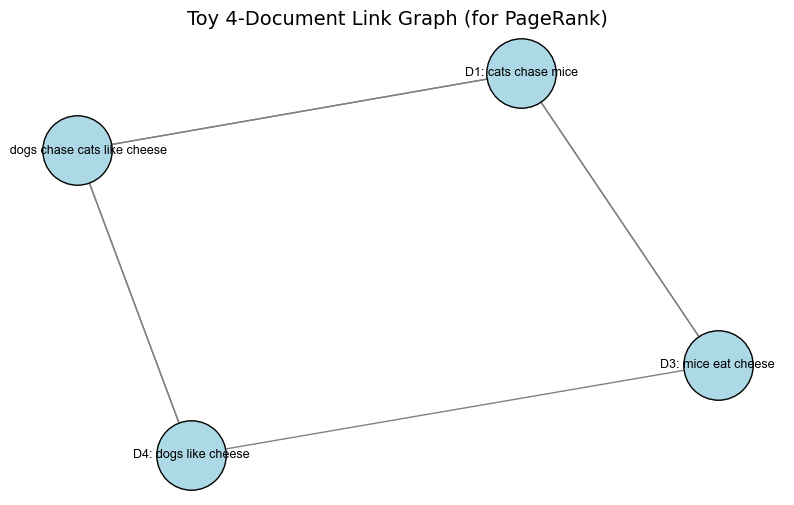

In [2]:
# ------------------------------------------------------------
# Visualize the 4-document PageRank toy graph using NetworkX
# ------------------------------------------------------------
# Requirements: pip install networkx matplotlib
# ------------------------------------------------------------

import networkx as nx
import matplotlib.pyplot as plt

# Define the graph edges (same as our PageRank toy example)
edges = [
    ("D1", "D2"),
    ("D1", "D3"),
    ("D2", "D1"),
    ("D2", "D4"),
    ("D3", "D1"),
    ("D4", "D2"),
    ("D4", "D3"),
]

# Create directed graph
G = nx.DiGraph()
G.add_edges_from(edges)

# Labels for clarity
labels = {
    "D1": "D1: cats chase mice",
    "D2": "D2: dogs chase cats like cheese",
    "D3": "D3: mice eat cheese",
    "D4": "D4: dogs like cheese",
}

# Layout (spring = force-directed, good for small graphs)
pos = nx.spring_layout(G, seed=42)

plt.figure(figsize=(10, 6))
nx.draw_networkx_nodes(G, pos, node_size=2500, node_color="lightblue", edgecolors="black")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, edge_color="gray")
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9, font_family="Arial")

plt.title("Toy 4-Document Link Graph (for PageRank)", fontsize=14)
plt.axis("off")
plt.show()


## PageRank: Intuition → Toy Computation

**Idea:** Imagine a *random surfer* who keeps clicking links. The importance of a page is the long-run fraction of time the surfer spends on it.

**Key pieces**
- **Link matrix (P):** \(P_{ij}\) = prob. of moving from page \(i\) to page \(j\) (row-stochastic).
- **Damping (α):** with prob. α follow a link; with prob. \(1-α\) *teleport* to any page (prevents traps & cycles).
- **Steady state:** find vector \( \pi \) such that \( \pi = \pi \cdot G \) where \( G = αP + (1-α)\frac{1}{N}\mathbf{1}\mathbf{1}^\top \).

**What we’ll do now**
1. Build a transition matrix from our **links** dict (D1…D4).  
2. Add **damping/teleport** to get the Google matrix.  
3. Run **power iteration** until the scores converge.  
4. Print each iteration’s vector (rounded) and final ranking.

We’ll keep it small and transparent—no external libraries—so students can trace the math.

---

## PageRank (Enhanced Visibility): print P, G, and each iteration’s math

To make PageRank *transparent*, we’ll print:

1) **Row-stochastic transition matrix P** (built from the link graph)  
2) **Google matrix G = α·P + (1−α)·J/N** (after damping/teleport)  
3) **Each power-iteration step** in a *visual* way:
   - Show the current vector \( \pi^{(k)} \) as a 1×N row
   - Show the matrix \( G \) as N×N
   - Print the multiplication \( \pi^{(k)} \cdot G \Rightarrow \pi^{(k+1)} \)
   - For each output component \( j \), expand the **sum of products**:
     \[
        \pi^{(k+1)}_j = \sum_i \pi^{(k)}_i \cdot G_{ij}
     \]
   - Report the L1 change \( \|\pi^{(k+1)} - \pi^{(k)}\|_1 \) and stop when below tolerance.

We’ll keep all of this with pure Python (no NumPy) so students can follow every number.

---


In [15]:
# ------------------------------------------------------------
# Block 11.1: PageRank with Rich Printing (Toy Graph, No NumPy)
# ------------------------------------------------------------
# What this block does (pedagogical printing):
# - Rebuilds P (row-stochastic) from the links dict.
# - Builds G with damping (alpha).
# - Prints P and G as labeled tables with page headers.
# - Runs power iteration and, at each step:
#     * Prints pi^(k) as a labeled 1×N row.
#     * Prints "pi^(k) × G = pi^(k+1)" visually.
#     * For each output component j, expands the sum of products:
#           pi_{k+1}[j] = sum_i pi_k[i] * G[i][j]
#     * Prints the L1 difference and stops on tolerance.
# - Designed for tiny N (like N=4) so verbosity is acceptable for teaching.
# ------------------------------------------------------------

# --- Helpers: formatted printing for vectors/matrices ---

def fmt(x, w=8, p=6):
    """Format a float with fixed width and precision for aligned printing."""
    return f"{x:{w}.{p}f}"

def print_vector(name, vec, labels):
    """Print a row vector with column labels."""
    # Header line
    header = [""] + labels
    print("  ".join(f"{h:>10s}" for h in header))
    # Vector line
    row = [name] + [fmt(x) for x in vec]
    print("  ".join(f"{c:>10s}" for c in row))
    print()

def print_matrix(name, M, row_labels, col_labels):
    """Print a matrix with both row and column labels."""
    header = [f"{name}→"] + col_labels
    print("  ".join(f"{h:>10s}" for h in header))
    for rl, row in zip(row_labels, M):
        cells = [rl] + [fmt(x) for x in row]
        print("  ".join(f"{c:>10s}" for c in cells))
    print()

def print_mult_step(pi_k, G, labels, k):
    """
    Print the multiplication pi^(k) × G = pi^(k+1)
    and expand each output component as a sum of products.
    """
    print(f"=== Iteration {k}: Multiply pi^(k-1) × G ===")
    print_vector(f"pi^{k-1}", pi_k, labels)
    print_matrix("G", G, row_labels=labels, col_labels=labels)

    # Compute the product and show per-component expansions
    N = len(labels)
    pi_next = [0.0] * N
    for j in range(N):
        terms = []
        s = 0.0
        for i in range(N):
            term = pi_k[i] * G[i][j]
            s += term
            terms.append(f"{fmt(pi_k[i], p=4)}×{fmt(G[i][j], p=4)}")
        pi_next[j] = s
        terms_str = " + ".join(terms)
        print(f"  pi^{k}[{labels[j]}] = {terms_str} = {fmt(s)}")
    print()
    return pi_next

# --- Build P and G again (so this cell is standalone/rerunnable) ---

pages = sorted(docs.keys())          # e.g., ['D1','D2','D3','D4']
index = {p:i for i,p in enumerate(pages)}
N = len(pages)

def row_stochastic_P(links_dict):
    """Row-stochastic P from links; dangling rows become uniform."""
    P = [[0.0 for _ in range(N)] for _ in range(N)]
    for src in pages:
        i = index[src]
        outs = links_dict.get(src, [])
        if outs:
            prob = 1.0 / len(outs)
            for dst in outs:
                P[i][index[dst]] = prob
        else:
            # Dangling node: uniform row
            for j in range(N):
                P[i][j] = 1.0 / N
    return P

def apply_damping(P, alpha=0.85):
    """G = alpha*P + (1-alpha)/N * J (J is all-ones)."""
    tele = (1.0 - alpha) / N
    G = [[alpha * P[i][j] + tele for j in range(N)] for i in range(N)]
    return G

def l1_diff(a, b):
    """L1 norm difference."""
    return sum(abs(x - y) for x, y in zip(a, b))

# Build and print P
alpha = 0.85
P = row_stochastic_P(links)
print("Row-stochastic transition matrix P:")
print_matrix("P", P, row_labels=pages, col_labels=pages)

# Build and print G
G = apply_damping(P, alpha=alpha)
print(f"Google matrix G (alpha={alpha}):")
print_matrix("G", G, row_labels=pages, col_labels=pages)

# Power iteration with verbose math
pi = [1.0 / N] * N
tol = 1e-6
max_iter = 100

print("Initial distribution:")
print_vector("pi^0", pi, labels=pages)

for k in range(1, max_iter + 1):
    # Print the multiplication step and expanded sums
    new_pi = print_mult_step(pi, G, labels=pages, k=k)
    delta = l1_diff(new_pi, pi)
    print(f"L1 change |pi^{k} - pi^{k-1}| = {delta:.6e}")
    print("-" * 72)
    pi = new_pi
    if delta < tol:
        print(f"Converged in {k} iterations (tol={tol}).")
        break

# Final scores and ranking
scores = list(zip(pages, pi))
scores.sort(key=lambda x: x[1], reverse=True)

print("\nFinal PageRank scores:")
for p, s in scores:
    print(f"  {p}: {s:.8f}")
print("Ranked order:", [p for p, _ in scores])


Row-stochastic transition matrix P:
        P→          D1          D2          D3          D4
        D1    0.000000    0.500000    0.500000    0.000000
        D2    0.500000    0.000000    0.000000    0.500000
        D3    1.000000    0.000000    0.000000    0.000000
        D4    0.000000    0.500000    0.500000    0.000000

Google matrix G (alpha=0.85):
        G→          D1          D2          D3          D4
        D1    0.037500    0.462500    0.462500    0.037500
        D2    0.462500    0.037500    0.037500    0.462500
        D3    0.887500    0.037500    0.037500    0.037500
        D4    0.037500    0.462500    0.462500    0.037500

Initial distribution:
                    D1          D2          D3          D4
      pi^0    0.250000    0.250000    0.250000    0.250000

=== Iteration 1: Multiply pi^(k-1) × G ===
                    D1          D2          D3          D4
      pi^0    0.250000    0.250000    0.250000    0.250000

        G→          D1          D2     

## BM25 Scoring on the Toy Corpus (with Intermediates)

We now compute **BM25** for a query on our toy corpus to show:
- Saturating **term frequency** and **length normalization** (via *k*, *b*).
- Clear **intermediate values** per document (idf, tf, length factors).
- Final **ranked list** (compare with earlier TF–IDF results).

**Formula (per term \(t\) in doc \(d\)):**
\[
\mathrm{BM25}(d,q)=\sum_{t\in q}
\underbrace{\ln\!\Big(1+\frac{N-df(t)+0.5}{df(t)+0.5}\Big)}_{\text{idf}(t)}
\cdot
\frac{\mathrm{tf}(t,d)\cdot (k+1)}
{\mathrm{tf}(t,d)+k\cdot\big(1-b+b\cdot \tfrac{|d|}{\text{avgdl}}\big)}
\]
We’ll use **\(k=1.2\)** and **\(b=0.75\)** (Lucene-style idf).


In [16]:
# ------------------------------------------------------------
# Block 10: BM25 Scoring (Toy Corpus) with Detailed Printing
# ------------------------------------------------------------
# What this block does:
# - Implements Lucene-style BM25 (k=1.2, b=0.75).
# - Uses the already-defined structures: docs, tokenized_docs, tf, df.
# - Prints intermediates for teaching: idf per term, per-doc length factors,
#   per-term contributions, and final scores.
# - Demonstrates the query "cats chase" to compare against earlier results.
# ------------------------------------------------------------

import math
from collections import Counter

# ---- Hyperparameters for BM25 (common, practical defaults) ----
K = 1.2    # term frequency saturation
B = 0.75   # length normalization strength

# ---- Corpus stats ----
N_docs = len(docs)                                        # total docs
doc_lengths = {d: sum(tf[d].values()) for d in tf}        # |d| = token count (post-normalization)
avgdl = sum(doc_lengths.values()) / max(N_docs, 1)        # average document length

# ---- Lucene-style IDF ----
def bm25_idf(term):
    """
    Lucene-style BM25 IDF:
      idf(t) = ln(1 + (N - df(t) + 0.5) / (df(t) + 0.5))
    This is robust for small corpora and avoids negative values for common terms.
    """
    df_t = df.get(term, 0)
    return math.log(1.0 + (N_docs - df_t + 0.5) / (df_t + 0.5))

def bm25_term_weight(tf_td, len_d):
    """
    BM25 term saturation + length normalization (without idf):
      ((k+1) * tf) / (tf + k * (1 - b + b * |d|/avgdl))
    """
    denom = tf_td + K * (1.0 - B + B * (len_d / max(avgdl, 1e-12)))
    return ((K + 1.0) * tf_td) / (denom if denom > 0 else 1.0)

def normalize_query_text(qtext):
    """
    Apply the SAME normalization as documents: lowercase + stopword removal.
    (Keeps behavior consistent with earlier blocks.)
    """
    return [w.lower() for w in qtext.split() if w.lower() not in stopwords]

def bm25_score(query_text, verbose=True):
    """
    End-to-end BM25 scoring with detailed prints:
      - Tokenize/normalize query
      - Compute idf for each unique query term
      - For each document:
          * print length, per-term tf, term weight, and contribution = idf * weight
      - Return sorted (doc, score)
    """
    q_terms = normalize_query_text(query_text)
    if not q_terms:
        if verbose: print("Empty query after normalization.")
        return []

    # Unique terms for idf table (BM25 sums over query terms; duplicate terms can be handled if needed)
    q_unique = list(Counter(q_terms).keys())
    if verbose:
        print(f"Query: {query_text!r} -> tokens: {q_terms}")
        print(f"N={N_docs}, avgdl={avgdl:.4f}\n")

        # Print IDF table
        print("=== IDF per query term ===")
        for t in q_unique:
            print(f"  idf({t}) = {bm25_idf(t):.6f}  (df={df.get(t,0)})")
        print()

    # Score each document
    scores = []
    for d in sorted(docs.keys()):
        len_d = doc_lengths.get(d, 0)
        score_d = 0.0
        per_term_lines = []

        for t in q_terms:
            tf_td = tf[d].get(t, 0)                   # term frequency in doc
            if tf_td == 0:
                # No contribution if term absent
                per_term_lines.append(f"    term={t:>6s} | tf=0 -> contrib=0")
                continue

            idf_t = bm25_idf(t)                       # rarity weight
            w_td  = bm25_term_weight(tf_td, len_d)    # saturation + length norm
            contrib = idf_t * w_td                    # per-term contribution
            score_d += contrib

            per_term_lines.append(
                f"    term={t:>6s} | tf={tf_td:>1d}  len={len_d:>2d}  "
                f"w_td={w_td:>8.5f}  idf={idf_t:>8.5f}  contrib={contrib:>8.5f}"
            )

        if verbose:
            print(f"--- Doc {d} ---  |d|={len_d}")
            for line in per_term_lines:
                print(line)
            print(f"  => BM25({d}) = {score_d:.6f}\n")

        scores.append((d, score_d))

    # Sort high → low
    scores.sort(key=lambda x: x[1], reverse=True)
    if verbose:
        print("Ranked results (BM25):", scores)
    return scores

# ---- Demo: same query used earlier to compare behaviors ----
_ = bm25_score("cats chase", verbose=True)


Query: 'cats chase' -> tokens: ['cats', 'chase']
N=4, avgdl=3.5000

=== IDF per query term ===
  idf(cats) = 0.693147  (df=2)
  idf(chase) = 0.693147  (df=2)

--- Doc D1 ---  |d|=3
    term=  cats | tf=1  len= 3  w_td= 1.06207  idf= 0.69315  contrib= 0.73617
    term= chase | tf=1  len= 3  w_td= 1.06207  idf= 0.69315  contrib= 0.73617
  => BM25(D1) = 1.472340

--- Doc D2 ---  |d|=5
    term=  cats | tf=1  len= 5  w_td= 0.85083  idf= 0.69315  contrib= 0.58975
    term= chase | tf=1  len= 5  w_td= 0.85083  idf= 0.69315  contrib= 0.58975
  => BM25(D2) = 1.179499

--- Doc D3 ---  |d|=3
    term=  cats | tf=0 -> contrib=0
    term= chase | tf=0 -> contrib=0
  => BM25(D3) = 0.000000

--- Doc D4 ---  |d|=3
    term=  cats | tf=0 -> contrib=0
    term= chase | tf=0 -> contrib=0
  => BM25(D4) = 0.000000

Ranked results (BM25): [('D1', 1.4723402180169873), ('D2', 1.179499069682117), ('D3', 0.0), ('D4', 0.0)]


## Blending BM25 (content) with PageRank (authority)

Modern rankers often **blend lexical relevance** (e.g., BM25) with **global authority** (PageRank).  
We’ll compute PageRank on our 4-page link graph and combine it with BM25 for a query.

**Blend (linear):**
\[
\text{FinalScore}(d) \;=\; \lambda \cdot \text{BM25}(d,q)\;+\;(1-\lambda)\cdot \widetilde{\pi}_d
\]
- \(\lambda \in [0,1]\) balances **content** vs **authority**.  
- \(\widetilde{\pi}_d\) is a **scaled** PageRank so magnitudes are comparable (we’ll min-max to \([0,1]\)).

We’ll print a compact table: **doc | BM25 | PR_raw | PR_scaled | FinalScore** and show the **ranked order**.


In [17]:
# ------------------------------------------------------------
# Block 12: Combine BM25 with PageRank (Toy Blend Demo)
# ------------------------------------------------------------
# What this block does:
# 1) Computes PageRank on our tiny link graph (pure Python).
# 2) Scores the current query with BM25 (reusing bm25_score()).
# 3) Scales PageRank to [0,1] (min-max) for a fair blend.
# 4) Combines with a tunable lambda and prints a clear table.
# ------------------------------------------------------------

from math import isclose

def compute_pagerank(links_dict, alpha=0.85, tol=1e-8, max_iter=100):
    """
    Simple PageRank (left-vector) via power iteration.
    - links_dict: {page: [outlinks]}
    - Returns: dict {page: pr_score}
    Notes:
      * Handles dangling nodes by uniform out-distribution.
      * Pure Python for transparency on tiny graphs.
    """
    pages = sorted(links_dict.keys())
    idx = {p:i for i,p in enumerate(pages)}
    N = len(pages)

    # Build row-stochastic P
    P = [[0.0]*N for _ in range(N)]
    for src in pages:
        i = idx[src]
        outs = links_dict.get(src, [])
        if outs:
            prob = 1.0/len(outs)
            for dst in outs:
                P[i][idx[dst]] = prob
        else:
            # Dangling: uniform row
            for j in range(N): P[i][j] = 1.0/N

    # Google matrix G = alpha*P + (1-alpha)/N * J
    tele = (1.0 - alpha)/N
    G = [[alpha*P[i][j] + tele for j in range(N)] for i in range(N)]

    # Power iteration on left-vector pi
    pi = [1.0/N]*N
    for _ in range(max_iter):
        new = [0.0]*N
        # new = pi * G  (row-vector × matrix)
        for j in range(N):
            s = 0.0
            for i in range(N):
                s += pi[i]*G[i][j]
            new[j] = s
        # convergence check (L1)
        delta = sum(abs(a-b) for a,b in zip(new, pi))
        pi = new
        if delta < tol:
            break

    return {p: pi[idx[p]] for p in pages}

def minmax_scale(d):
    """
    Min-max scale a dict of {key: value} to [0,1].
    If all values equal, return zeros to avoid division by zero.
    """
    vals = list(d.values())
    lo, hi = min(vals), max(vals)
    if isclose(lo, hi):
        return {k: 0.0 for k in d}
    return {k: (v - lo)/(hi - lo) for k,v in d.items()}

# --- 1) Compute PageRank on our current toy links ---
pr = compute_pagerank(links, alpha=0.85)
pr_scaled = minmax_scale(pr)

# --- 2) BM25 on the same query (use earlier helper) ---
query = "cats chase"
bm25_scores = dict(bm25_score(query, verbose=False))  # quiet; we only need numbers

# --- 3) Blend with a tunable lambda ---
lam = 0.8  # heavier weight on lexical content for this toy; tweak to taste

# Prepare a clear table of components and final scores
rows = []
for d in sorted(docs.keys()):
    bm = bm25_scores.get(d, 0.0)
    pr_raw = pr.get(d, 0.0)
    pr_s = pr_scaled.get(d, 0.0)
    final = lam*bm + (1.0 - lam)*pr_s
    rows.append((d, bm, pr_raw, pr_s, final))

# Sort by final score desc
rows.sort(key=lambda r: r[4], reverse=True)

# Print a compact table
hdr = f"{'Doc':<4} | {'BM25':>8} | {'PR_raw':>8} | {'PR_scaled':>10} | {'FinalScore':>11}"
print(hdr)
print("-"*len(hdr))
for d, bm, pr_raw, pr_s, final in rows:
    print(f"{d:<4} | {bm:8.5f} | {pr_raw:8.5f} | {pr_s:10.5f} | {final:11.5f}")

# Also show the ranked order for quick reading
print("\nRanked order (blend λ=%.2f):" % lam, [d for d, *_ in rows])


Doc  |     BM25 |   PR_raw |  PR_scaled |  FinalScore
-----------------------------------------------------
D1   |  1.47234 |  0.35625 |    1.00000 |     1.37787
D2   |  1.17950 |  0.25000 |    0.50000 |     1.04360
D3   |  0.00000 |  0.25000 |    0.50000 |     0.10000
D4   |  0.00000 |  0.14375 |    0.00000 |     0.00000

Ranked order (blend λ=0.80): ['D1', 'D2', 'D3', 'D4']


## Semantic Retrieval (Dense Vectors) — Intuition + Tiny Hybrid Demo

**Why semantic features?**  
Bag-of-words (TF-IDF/BM25) match exact tokens. They miss meaning like *“felines hunt rodents”* ≈ *“cats chase mice.”*  
Dense methods map text to vectors so **similar meaning → nearby vectors**.

**Two common patterns**
- **Dual encoders (bi-encoders):** encode query and docs separately; retrieve by vector similarity (e.g., cosine). Fast with ANN.
- **Cross encoders:** re-rank a small candidate set using a deeper model that sees *query + doc together*. More accurate, slower.

**Hybrid retrieval** blends sparse (BM25) + dense (semantic) to get the best of both worlds:
\[
\text{Hybrid}(d) = \lambda\cdot \text{BM25}(d,q) \;+\; (1-\lambda)\cdot \text{SemanticSim}(q,d)
\]

Below, we’ll do a **toy dense demo** with a *hand-crafted mini-embedding space* for our vocabulary to show the mechanics (no external libs).


In [18]:
# ------------------------------------------------------------
# Block 13: Toy Semantic Retrieval + Hybrid with BM25
# ------------------------------------------------------------
# What this block does:
# - Builds a *tiny, hand-crafted* embedding for key words in our corpus.
# - Encodes query and documents by averaging word vectors (a classic/simple baseline).
# - Computes cosine similarity as the semantic score.
# - Combines it with BM25 via a weighted hybrid and prints a neat table.
#
# Notes:
# - This is purely pedagogical. Real systems learn embeddings from data (e.g., SBERT).
# - We keep vectors 3D for easy inspection; directions capture rough synonymy.
# ------------------------------------------------------------

import math
from collections import Counter

# --- 1) Hand-crafted mini-embeddings for demo (toy, interpretable) ---
# Intuition:
# - "cats" near "feline"; "mice" near "rodents"; "chase" near "hunt".
# - "dogs" placed differently to capture non-synonym relation to "cats".
emb = {
    "cats":    ( 0.90,  0.10,  0.00),
    "feline":  ( 0.92,  0.10,  0.00),
    "dogs":    (-0.80,  0.05,  0.00),
    "mice":    ( 0.10,  0.90,  0.00),
    "rodents": ( 0.10,  0.92,  0.00),
    "cheese":  ( 0.00,  0.70,  0.10),
    "chase":   ( 0.40,  0.20,  0.70),
    "hunt":    ( 0.42,  0.18,  0.72),
    "eat":     ( 0.05,  0.50,  0.20),
    "like":    ( 0.00,  0.10,  0.05),
}

# --- 2) Utility: vector ops and encoding by mean pooling ---
def vadd(a, b):
    return tuple(x+y for x, y in zip(a, b))

def vscale(a, s):
    return tuple(s*x for x in a)

def vmean(vs):
    if not vs: 
        return (0.0, 0.0, 0.0)
    n = len(vs)
    s = (0.0, 0.0, 0.0)
    for v in vs:
        s = vadd(s, v)
    return vscale(s, 1.0/n)

def vdot(a, b):
    return sum(x*y for x, y in zip(a, b))

def vnorm(a):
    return math.sqrt(vdot(a, a)) or 1e-12

def vcos(a, b):
    return vdot(a, b) / (vnorm(a) * vnorm(b))

def encode_text(tokens):
    """
    Encode a piece of text by averaging embeddings of known tokens.
    Unknown tokens are skipped (classic baseline).
    """
    vecs = [emb[t] for t in tokens if t in emb]
    return vmean(vecs)

# --- 3) Normalize query like before, and allow lightweight synonym expansion ---
synonyms = {
    "cats": ["feline"],
    "mice": ["rodents"],
    "chase": ["hunt"],
}
def expand_query_terms(q_terms):
    """
    Expand query with a small set of synonyms (equal weight for demo).
    Real systems might weight expansions lower or learn them.
    """
    expanded = list(q_terms)
    for t in q_terms:
        for s in synonyms.get(t, []):
            expanded.append(s)
    return expanded

def normalize_query_text(qtext):
    return [w.lower() for w in qtext.split() if w.lower() not in stopwords]

# --- 4) Compute semantic similarity for our docs vs a query ---
def semantic_scores(query_text, use_expansion=True, verbose=True):
    q_terms = normalize_query_text(query_text)
    q_terms_exp = expand_query_terms(q_terms) if use_expansion else q_terms
    q_vec = encode_text(q_terms_exp)

    if verbose:
        print(f"Query: {query_text!r}")
        print(f"  tokens: {q_terms}")
        if use_expansion:
            print(f"  expanded: {q_terms_exp}")
        print(f"  q_vec: {tuple(round(x,4) for x in q_vec)}\n")

    scores = []
    for d in sorted(docs.keys()):
        # Use the already normalized tokens from earlier blocks
        toks = tokenized_docs[d]
        d_vec = encode_text(toks)
        sim = vcos(q_vec, d_vec)
        scores.append((d, sim))
        if verbose:
            print(f"Doc {d}: tokens={toks}")
            print(f"  d_vec: {tuple(round(x,4) for x in d_vec)}  ->  cos={sim:.5f}\n")

    scores.sort(key=lambda x: x[1], reverse=True)
    if verbose:
        print("Ranked results (Semantic cosine):", scores, "\n")
    return scores

# --- 5) Hybrid BM25 + Semantic ---
def hybrid_bm25_semantic(query_text, lam=0.7):
    """
    Combine BM25 (content) and Semantic cosine (authority-of-meaning) via:
      Hybrid = lam * BM25_norm + (1-lam) * Sem_norm
    We min-max normalize each list to [0,1] before blending for fairness.
    """
    # BM25 raw scores
    bm25_raw = dict(bm25_score(query_text, verbose=False))
    # Semantic raw scores
    sem_raw = dict(semantic_scores(query_text, verbose=False))

    # Min-max normalize helpers
    def minmax(d):
        vals = list(d.values())
        lo, hi = min(vals), max(vals)
        if abs(hi - lo) < 1e-12:
            return {k: 0.0 for k in d}
        return {k: (v - lo)/(hi - lo) for k, v in d.items()}

    bm25_n = minmax(bm25_raw)
    sem_n  = minmax(sem_raw)

    # Blend and print table
    rows = []
    hdr = f"{'Doc':<4} | {'BM25':>8} | {'BM25_n':>7} | {'Sem':>8} | {'Sem_n':>7} | {'Hybrid':>8}"
    print(hdr)
    print("-"*len(hdr))
    for d in sorted(docs.keys()):
        b = bm25_raw.get(d, 0.0)
        bn = bm25_n.get(d, 0.0)
        s = sem_raw.get(d, 0.0)
        sn = sem_n.get(d, 0.0)
        h = lam*bn + (1.0 - lam)*sn
        rows.append((d, h))
        print(f"{d:<4} | {b:8.5f} | {bn:7.4f} | {s:8.5f} | {sn:7.4f} | {h:8.5f}")

    rows.sort(key=lambda r: r[1], reverse=True)
    print("\nRanked order (Hybrid):", [d for d, _ in rows])
    return rows

# --- 6) Demo on our canonical query ---
print("=== Semantic-only ===")
_ = semantic_scores("cats chase", use_expansion=True, verbose=True)

print("\n=== Hybrid BM25 + Semantic ===")
_ = hybrid_bm25_semantic("cats chase", lam=0.7)


=== Semantic-only ===
Query: 'cats chase'
  tokens: ['cats', 'chase']
  expanded: ['cats', 'chase', 'feline', 'hunt']
  q_vec: (0.66, 0.145, 0.355)

Doc D1: tokens=['cats', 'chase', 'mice']
  d_vec: (0.4667, 0.4, 0.2333)  ->  cos=0.89439

Doc D2: tokens=['dogs', 'chase', 'cats', 'like', 'cheese']
  d_vec: (0.1, 0.23, 0.17)  ->  cos=0.69053

Doc D3: tokens=['mice', 'eat', 'cheese']
  d_vec: (0.05, 0.7, 0.1)  ->  cos=0.31418

Doc D4: tokens=['dogs', 'like', 'cheese']
  d_vec: (-0.2667, 0.2833, 0.05)  ->  cos=-0.39129

Ranked results (Semantic cosine): [('D1', 0.8943915381368994), ('D2', 0.6905254668214539), ('D3', 0.31417889863902465), ('D4', -0.3912880343057026)] 


=== Hybrid BM25 + Semantic ===
Doc  |     BM25 |  BM25_n |      Sem |   Sem_n |   Hybrid
---------------------------------------------------------
D1   |  1.47234 |  1.0000 |  0.89439 |  1.0000 |  1.00000
D2   |  1.17950 |  0.8011 |  0.69053 |  0.8414 |  0.81320
D3   |  0.00000 |  0.0000 |  0.31418 |  0.5487 |  0.16461
D4   

## Evaluation Metrics (Toy) — Precision@k, MAP, nDCG

To reason about rank quality, we’ll add **standard IR metrics** on our toy corpus.

**Why metrics?**  
A ranking looks convincing, but we need numbers to compare variants (e.g., TF-IDF vs BM25 vs Hybrid).

**We’ll compute**
- **Precision@k**: fraction of the top-k results that are relevant.  
- **Average Precision (AP)** per query: average of precision at each rank where a relevant doc occurs.  
- **Mean Average Precision (MAP)**: mean AP over a set of queries.  
- **nDCG@k** (normalized Discounted Cumulative Gain): supports **graded relevance** (e.g., 2 = highly relevant, 1 = relevant).

**Toy qrels (graded relevance, hand-set)**
- `q1 = "cats chase"` → D1: **2**, D2: **1** (others: 0)  
- `q2 = "cheese"` → D3: **2**, D4: **1** (others: 0)  
- `q3 = "dogs"` → D2: **2**, D4: **1** (others: 0)

We’ll evaluate **BM25** as our baseline ranker on these queries and report per-query and aggregate metrics.


In [19]:
# ------------------------------------------------------------
# Block 14: IR Metrics on the Toy Corpus (Precision@k, MAP, nDCG)
# ------------------------------------------------------------
# What this block does:
# 1) Defines a tiny set of *graded* relevances (qrels) for 3 toy queries.
# 2) Implements common IR metrics:
#       - Precision@k
#       - Average Precision (AP)
#       - Mean Average Precision (MAP)
#       - nDCG@k (supports graded relevance)
# 3) Uses BM25 (from earlier block) to rank docs for each query.
# 4) Prints a clear per-query table and aggregate metrics.
#
# Notes:
# - We reuse bm25_score(query, verbose=False) from Block 10.
# - Relevance scale: 0 (non-relevant), 1 (relevant), 2 (highly relevant).
# - Adjust K, B or qrels as you wish for different classroom demos.
# ------------------------------------------------------------

import math

# -------------------------------
# (1) Toy graded relevance (qrels)
# -------------------------------
qrels = {
    "cats chase": {"D1": 2, "D2": 1},        # D1 highly relevant; D2 relevant
    "cheese":     {"D3": 2, "D4": 1},        # D3 highly relevant; D4 relevant
    "dogs":       {"D2": 2, "D4": 1},        # D2 highly relevant; D4 relevant
}

all_docs = sorted(docs.keys())

# -----------------------------------------
# (2) Metric helpers (Precision/AP/MAP/nDCG)
# -----------------------------------------

def precision_at_k(ranked_docs, rel_dict, k=3):
    """
    Precision@k:
      (# of relevant docs in top-k) / k
    rel_dict: {doc_id: graded_rel} (>=1 counts as relevant for precision)
    """
    k = max(1, min(k, len(ranked_docs)))
    topk = ranked_docs[:k]
    rel_hits = sum(1 for d in topk if rel_dict.get(d, 0) > 0)
    return rel_hits / k

def average_precision(ranked_docs, rel_dict):
    """
    Average Precision (AP):
      Mean of precision@i at each rank i where the document is relevant.
    rel_dict: graded relevance; we treat >=1 as relevant for AP.
    """
    num_rel = sum(1 for d in all_docs if rel_dict.get(d, 0) > 0)
    if num_rel == 0:
        return 0.0
    ap_sum, hits = 0.0, 0
    for i, d in enumerate(ranked_docs, start=1):
        if rel_dict.get(d, 0) > 0:
            hits += 1
            ap_sum += hits / i   # precision@i (since each hit increments hits)
    return ap_sum / num_rel

def dcg_at_k(ranked_docs, rel_dict, k=3):
    """
    DCG@k with log2 discount and graded gains:
      DCG = sum_{i=1..k} (gain_i / log2(i+1)),  gain = rel
    """
    k = max(1, min(k, len(ranked_docs)))
    dcg = 0.0
    for i, d in enumerate(ranked_docs[:k], start=1):
        gain = float(rel_dict.get(d, 0))
        denom = math.log2(i + 1)  # log2(2)=1 for rank 1
        dcg += gain / denom
    return dcg

def ndcg_at_k(ranked_docs, rel_dict, k=3):
    """
    nDCG@k:
      DCG@k / IDCG@k, where IDCG is DCG of the ideal ranking (sorted by rel desc).
    """
    ideal = sorted(all_docs, key=lambda d: rel_dict.get(d, 0), reverse=True)
    dcg  = dcg_at_k(ranked_docs, rel_dict, k)
    idcg = dcg_at_k(ideal,       rel_dict, k)
    return (dcg / idcg) if idcg > 0 else 0.0

# -----------------------------------------
# (3) Evaluate BM25 for each query in qrels
# -----------------------------------------

def evaluate_ranker(rank_fn, queries, ks=(1, 2, 3, 4)):
    """
    rank_fn: callable(query_text) -> list of (doc_id, score) sorted high→low
    queries: iterable of query strings
    ks: tuple of cutoffs for Precision@k and nDCG@k
    """
    results = []
    map_sum = 0.0

    for q in queries:
        # Run the ranker and extract the ranked doc IDs
        ranked = [d for d, _ in rank_fn(q)]
        rel = qrels.get(q, {})

        # Compute metrics
        ap = average_precision(ranked, rel)
        map_sum += ap

        precs = {f"P@{k}": precision_at_k(ranked, rel, k=k) for k in ks}
        ndcgs = {f"nDCG@{k}": ndcg_at_k(ranked, rel, k=k) for k in ks}

        results.append({
            "query": q,
            "AP": ap,
            **precs,
            **ndcgs,
            "ranked": ranked,
        })

    MAP = map_sum / max(1, len(queries))
    return results, MAP

# Simple wrapper using earlier bm25_score() (quiet mode)
def rank_with_bm25(query_text):
    scores = bm25_score(query_text, verbose=False)
    return scores  # list of (doc, score), already sorted

# -----------------------------------------
# (4) Run evaluation and print a tidy summary
# -----------------------------------------

queries = list(qrels.keys())
results, MAP = evaluate_ranker(rank_with_bm25, queries, ks=(1, 2, 3, 4))

# Pretty print per-query metrics
print("=== Per-Query Metrics (BM25) ===")
hdr = f"{'Query':<15} | {'AP':>6} | {'P@1':>6} {'P@2':>6} {'P@3':>6} {'P@4':>6} | {'nDCG@1':>7} {'nDCG@2':>7} {'nDCG@3':>7} {'nDCG@4':>7}"
print(hdr)
print("-" * len(hdr))

for r in results:
    print(f"{r['query']:<15} | {r['AP']:6.3f} | "
          f"{r['P@1']:6.3f} {r['P@2']:6.3f} {r['P@3']:6.3f} {r['P@4']:6.3f} | "
          f"{r['nDCG@1']:7.3f} {r['nDCG@2']:7.3f} {r['nDCG@3']:7.3f} {r['nDCG@4']:7.3f}")

# Print MAP and the ranked lists for transparency
print("\nMAP (BM25 over all queries): %.3f" % MAP)
print("\nRanked lists:")
for r in results:
    print(f"  {r['query']!r}: {r['ranked']}")


=== Per-Query Metrics (BM25) ===
Query           |     AP |    P@1    P@2    P@3    P@4 |  nDCG@1  nDCG@2  nDCG@3  nDCG@4
----------------------------------------------------------------------------------------
cats chase      |  1.000 |  1.000  1.000  0.667  0.500 |   1.000   1.000   1.000   1.000
cheese          |  1.000 |  1.000  1.000  0.667  0.500 |   1.000   1.000   1.000   1.000
dogs            |  1.000 |  1.000  1.000  0.667  0.500 |   0.500   0.860   0.860   0.860

MAP (BM25 over all queries): 1.000

Ranked lists:
  'cats chase': ['D1', 'D2', 'D3', 'D4']
  'cheese': ['D3', 'D4', 'D2', 'D1']
  'dogs': ['D4', 'D2', 'D1', 'D3']
